# Statistics for comment reviews

In [1]:
# Libraries
library(tidyverse)
library(reshape2)
library(grid)
library(DescTools)
library(rcompanion)
library(psych)

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.0     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.1     ✔ tibble    3.1.8
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths


Warning message:
“package ‘DescTools’ was built under R version 4.2.3”
Warning message:
“package ‘rcompanion’ was built under R version 4.2.3”
Warning message:
“package ‘psych’ was built under R version 4.2.3”

Attaching package: ‘psych’


The following object is masked from ‘package:r

In [4]:
# Data
df <- read.delim("counts.lca.rarefy.tsv")

# Sum values
dfsum <- df[,c(1,9:23)] %>% group_by(superkingdom) %>% summarise_if(is.numeric, sum, na.rm=F)
dfsum

# Total
total_reads <- sum(df[23])

superkingdom,OP0.2A,OP0.2B,OP0.2C,OP1.2A,OP1.2B,OP1.2C,OP5.0A,OP5.0B,OP5.0C,OP8.0A,OP8.0B,OP8.0C,EN0.2A,EN0.2B,EN0.2C
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Archaea,10154,11102,9600,4657,4606,1959,2386,2400,1388,2240,1764,1640,11016,8815,8975
Bacteria,417375,410156,420281,204465,172121,379834,90582,101783,349256,102224,90296,344748,448268,402086,473951
Eukaryota,110947,118069,108997,277708,334864,159061,317593,332845,157448,323328,400512,177438,113212,165304,91350
Viruses,45369,44719,44549,96574,71909,41602,174053,147359,75295,156673,92215,59474,11228,7513,9037
NA,1299,1098,1717,1740,1644,2688,530,757,1757,679,357,1844,1420,1426,1831


*Trend plots*

Using superkingdom as id variables



png 
  2

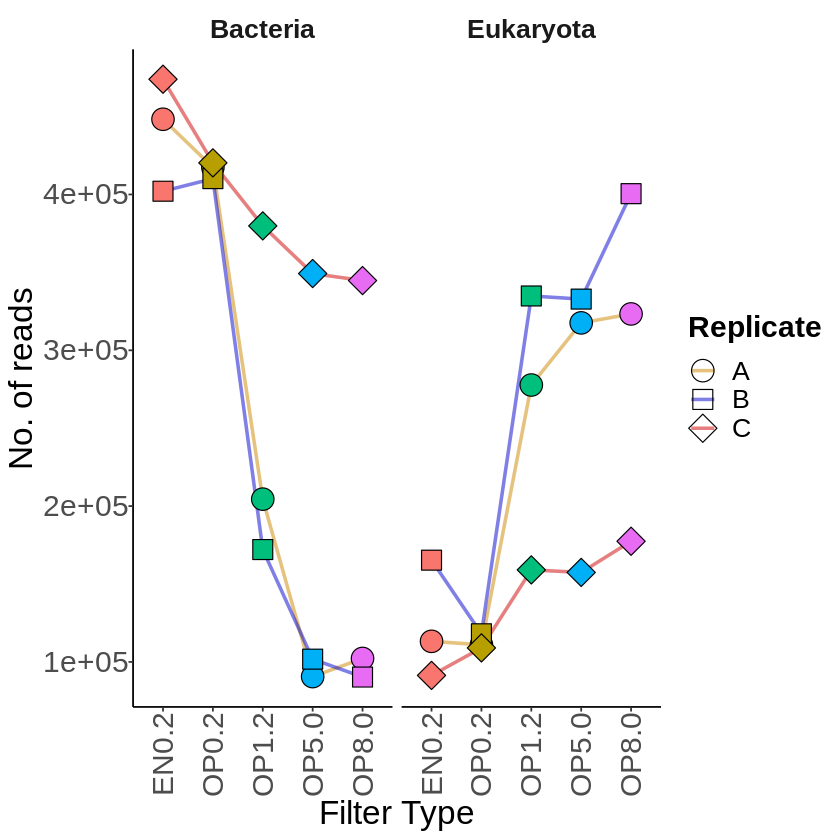

In [6]:
dfm <- dfsum %>% melt() %>% mutate(cat = substr(variable, 1, 5), rep = substr(variable, 6, 6)) %>% filter(superkingdom %in% c('Bacteria','Eukaryota'))
dfm$cat <- factor(dfm$cat, levels = c("EN0.2", "OP0.2", "OP1.2", "OP5.0", "OP8.0"))

p <- dfm %>%	ggplot(aes(x=cat, y=value, group=rep, fill=cat), color="black") + 
geom_line(aes(color=rep), linewidth=1, alpha=0.5) + geom_point(aes(shape=rep), size=6) + facet_grid(~superkingdom) +
scale_shape_manual(values = c(21,22,23)) +
scale_fill_manual(values = c("#F8766D", "#B79F00", "#00BF7D", "#00B0F6", "#E76BF3")) +
scale_color_manual(values = c("orange3", "blue3", "red3")) +
guides(fill = "none") +
labs(x="Filter Type", y = "No. of reads", fill="", color="Replicate", shape="Replicate") +
theme_classic() %+replace% theme(axis.text.x = element_text(angle = 90, size=18),
                                 axis.text.y = element_text(size=18),
                                 axis.title = element_text(size=20),
                                 strip.text.x = element_text(size = 16, face="bold"),
                                 strip.background = element_blank(),
                                 legend.title = element_text(size=18, face="bold"),
                                 legend.text = element_text(size=16))

png(file="trend_plot.pores_and_reps.rarefied.png", width=2300, height=2000, res=300)
p
dev.off()
p

*Compute Abstract values*

In [24]:
# Bacteria
x <- dfsum %>% melt() %>% mutate(cat = substr(variable, 1,5)) %>% mutate(porecat = ifelse(cat %in% c('EN0.2','OP0.2','OP1.2'), 'Low', 'High')) %>% filter(superkingdom == "Bacteria") %>% group_by(porecat) %>% summarize(mean_bact = mean(value), std_bact = sd(value))
x

Using superkingdom as id variables



porecat,mean_bact,std_bact
<chr>,<dbl>,<dbl>
High,179814.8,129613.8
Low,369837.4,106654.0


In [29]:
369837.4 / (179814.8+369837.4) * 100

[1] 67.28571

In [31]:
((369837.4 - 179814.8) / 179814.8) * 100

[1] 105.6768

In [28]:
(369837.4 / 179814.8)

[1] 2.056768

In [36]:
# Eukaryota
dfsum %>% melt() %>% mutate(cat = substr(variable, 1,5)) %>% mutate(porecat = ifelse(cat %in% c('EN0.2','OP0.2','OP1.2'), 'Low', 'High')) %>% filter(superkingdom == "Eukaryota") %>% group_by(porecat) %>% summarize(mean_bact = mean(value), std_bact = sd(value))

Using superkingdom as id variables



porecat,mean_bact,std_bact
<chr>,<dbl>,<dbl>
High,284860.7,95919.22
Low,164390.2,85114.47


In [14]:
284860.7 / (164390.2+284860.7) * 100

[1] 63.40793

In [34]:
((284860.7 - 164390.2) / 164390.2) * 100

[1] 73.28326

*SIGN test*

In [17]:
suppressMessages(library(BSDA))
# Sign test: Bacteria 0.2 vs 0.8
SIGN.test(x = c(417375,410156,420281), md = median(c(102224,90296,344748)), conf.level = 0.95, alternative = "two.sided")


	One-sample Sign-Test

data:  c(417375, 410156, 420281)
s = 3, p-value = 0.25
alternative hypothesis: true median is not equal to 102224
75 percent confidence interval:
 410156 420281
sample estimates:
median of x 
     417375 

In [16]:
# Sign test: Eukaryota  0.8 vs 02
SIGN.test(x = c(323328, 400512, 177438), md = median(c(110947, 118069, 108997)), conf.level = 0.95, alternative = "two.sided")


	One-sample Sign-Test

data:  c(323328, 400512, 177438)
s = 3, p-value = 0.25
alternative hypothesis: true median is not equal to 110947
75 percent confidence interval:
 177438 400512
sample estimates:
median of x 
     323328 

In [25]:
SIGN.test(x = c(417375,410156,420281), md = median(c(110947, 118069, 108997)), conf.level = 0.95, alternative = "two.sided")


	One-sample Sign-Test

data:  c(417375, 410156, 420281)
s = 3, p-value = 0.25
alternative hypothesis: true median is not equal to 110947
75 percent confidence interval:
 410156 420281
sample estimates:
median of x 
     417375 

*Wilcoxon test: Superkingdom*

In [42]:
wilcoxon_test_spk_groups <- function(data, spk) {
	message(paste("Wilcoxon test for", spk))
	# Rename kingdoms
	data$superkingdom[is.na(data$superkingdom)] <- "Unknown"
	# Filter data
	data <- data %>% melt() %>% mutate(variable = substr(variable, 1, 5)) %>% mutate(porecat = ifelse(variable %in% c('EN0.2','OP0.2','OP1.2'), 'Low', 'High')) %>% filter(superkingdom == spk)
	# Split data
	k1 <- data$value[data$porecat == "Low"]
	k2 <- data$value[data$porecat == "High"]
	# Print
	print(k1)
	print(k2)
	# Mean and sd
	print(paste(round(mean(k1),2), "±", round(sd(k1),2)))
	print(paste(round(mean(k2),2), "±", round(sd(k2),2)))
	# Wilcoxon test
	res <- wilcox.test(k1, k2)
	# Return results
	print(res)
	return(res)
}

In [43]:
# Wilcoxon between groups
wil_arch <- wilcoxon_test_spk_groups(dfsum, "Archaea")
wil_arch

message("")
message("---------------------")
message("---------------------")
message("")

wil_bact <- wilcoxon_test_spk_groups(dfsum, "Bacteria")
wil_bact

message("")
message("---------------------")
message("---------------------")
message("")

wil_euka <- wilcoxon_test_spk_groups(dfsum, "Eukaryota")
wil_euka

message("")
message("---------------------")
message("---------------------")
message("")

wil_viru <- wilcoxon_test_spk_groups(dfsum, "Viruses")
wil_viru

message("")
message("---------------------")
message("---------------------")
message("")

wil_unkn <- wilcoxon_test_spk_groups(dfsum, "Unknown")
wil_unkn

Wilcoxon test for Archaea

Using superkingdom as id variables



[1] 10154 11102  9600  4657  4606  1959 11016  8815  8975
[1] 2386 2400 1388 2240 1764 1640
[1] "7876 ± 3289.82"
[1] "1969.67 ± 429.17"

	Wilcoxon rank sum exact test

data:  k1 and k2
W = 51, p-value = 0.002797
alternative hypothesis: true location shift is not equal to 0




	Wilcoxon rank sum exact test

data:  k1 and k2
W = 51, p-value = 0.002797
alternative hypothesis: true location shift is not equal to 0




---------------------

---------------------



Wilcoxon test for Bacteria

Using superkingdom as id variables



[1] 417375 410156 420281 204465 172121 379834 448268 402086 473951
[1]  90582 101783 349256 102224  90296 344748
[1] "369837.44 ± 106654.04"
[1] "179814.83 ± 129613.8"

	Wilcoxon rank sum exact test

data:  k1 and k2
W = 50, p-value = 0.004795
alternative hypothesis: true location shift is not equal to 0



...

[1] 45369 44719 44549 96574 71909 41602 11228  7513  9037
[1] 174053 147359  75295 156673  92215  59474
[1] "41388.89 ± 29828.12"
[1] "117511.5 ± 47774.33"

	Wilcoxon rank sum exact test

data:  k1 and k2
W = 4, p-value = 0.004795
alternative hypothesis: true location shift is not equal to 0




	Wilcoxon rank sum exact test

data:  k1 and k2
W = 4, p-value = 0.004795
alternative hypothesis: true location shift is not equal to 0




---------------------

---------------------



Wilcoxon test for Unknown

Using superkingdom as id variables



[1] 1299 1098 1717 1740 1644 2688 1420 1426 1831
[1]  530  757 1757  679  357 1844
[1] "1651.44 ± 454.67"
[1] "987.33 ± 645.11"

	Wilcoxon rank sum exact test

data:  k1 and k2
W = 39, p-value = 0.181
alternative hypothesis: true location shift is not equal to 0




	Wilcoxon rank sum exact test

data:  k1 and k2
W = 39, p-value = 0.181
alternative hypothesis: true location shift is not equal to 0


In [46]:
# P-value correction
pvals <- c(wil_arch$p.value, wil_bact$p.value, wil_euka$p.value, wil_viru$p.value, wil_unkn$p.value)
p.adjust(pvals, method = "BH", n = length(pvals))

[1] 0.007992008 0.007992008 0.044955045 0.007992008 0.181018981

In [47]:
wilcoxon_test <- function(data, pore, spk1, spk2) {
	# Filter data
	data <- data %>% melt() %>% mutate(variable = substr(variable, 1, 5)) %>% filter(variable == pore) %>% drop_na()
	# Boxplot
	print(data %>% filter(superkingdom %in% c(spk1, spk2)) %>% ggplot() + geom_boxplot(aes(x=superkingdom, y=value)))
	# Split data
	spk1 <- data$value[data$superkingdom == spk1]
	spk2 <- data$value[data$superkingdom == spk2]
	# Wilcoxon test
	res <- wilcox.test(spk1, spk2)
	# Return results
	return(res)
}

Using superkingdom as id variables




	Wilcoxon rank sum exact test

data:  spk1 and spk2
W = 9, p-value = 0.1
alternative hypothesis: true location shift is not equal to 0




---------------------

---------------------



Using superkingdom as id variables



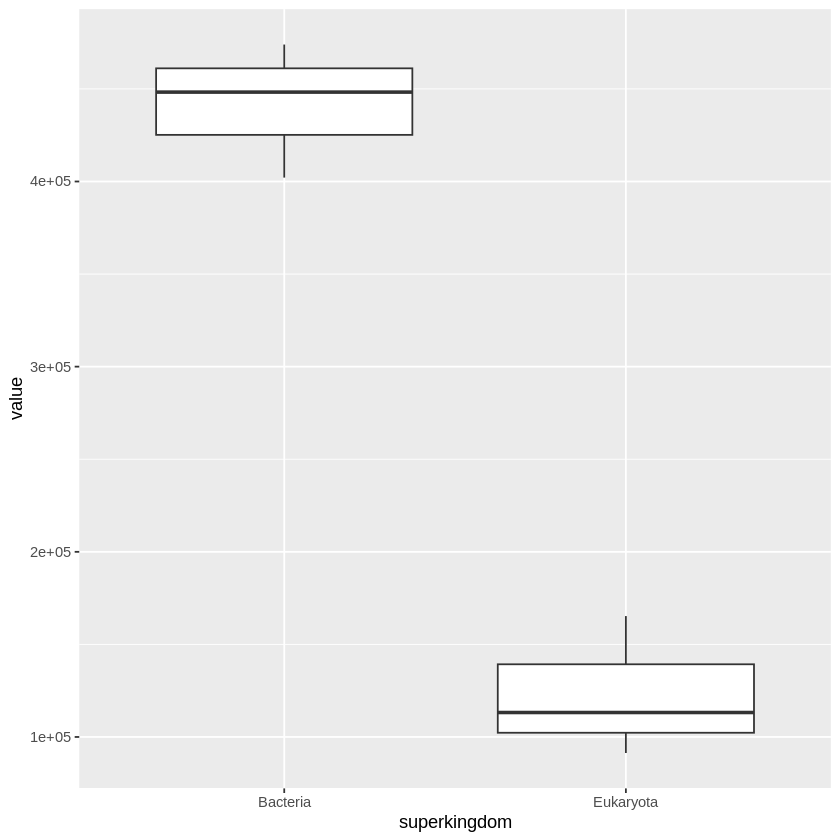


	Wilcoxon rank sum exact test

data:  spk1 and spk2
W = 9, p-value = 0.1
alternative hypothesis: true location shift is not equal to 0




---------------------

---------------------



Using superkingdom as id variables



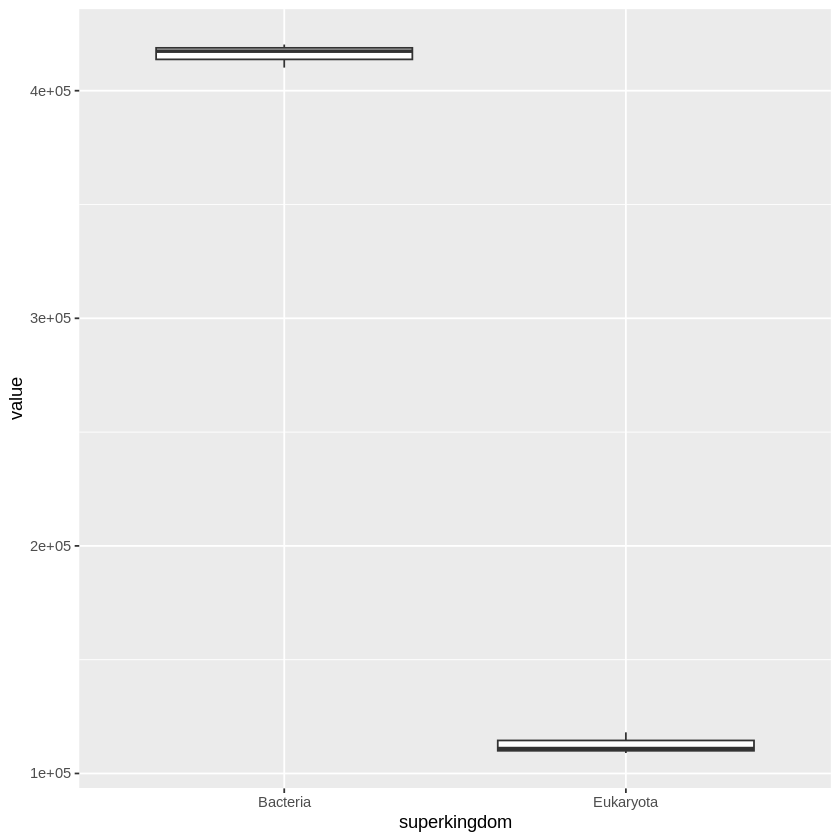


	Wilcoxon rank sum exact test

data:  spk1 and spk2
W = 5, p-value = 1
alternative hypothesis: true location shift is not equal to 0




---------------------

---------------------



Using superkingdom as id variables



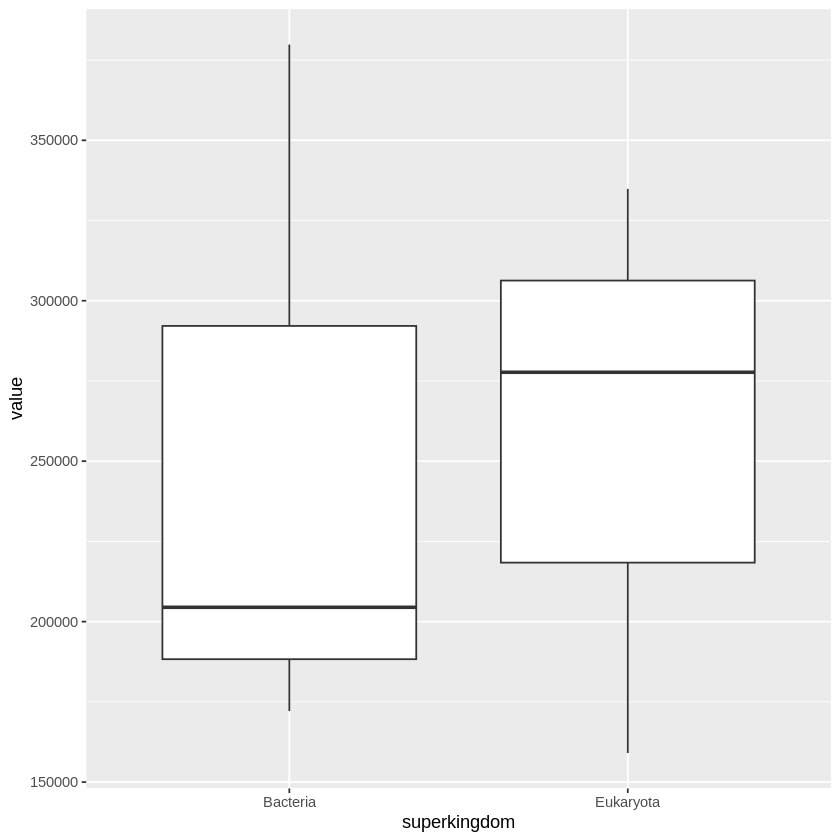


	Wilcoxon rank sum exact test

data:  spk1 and spk2
W = 3, p-value = 0.7
alternative hypothesis: true location shift is not equal to 0




---------------------

---------------------



Using superkingdom as id variables



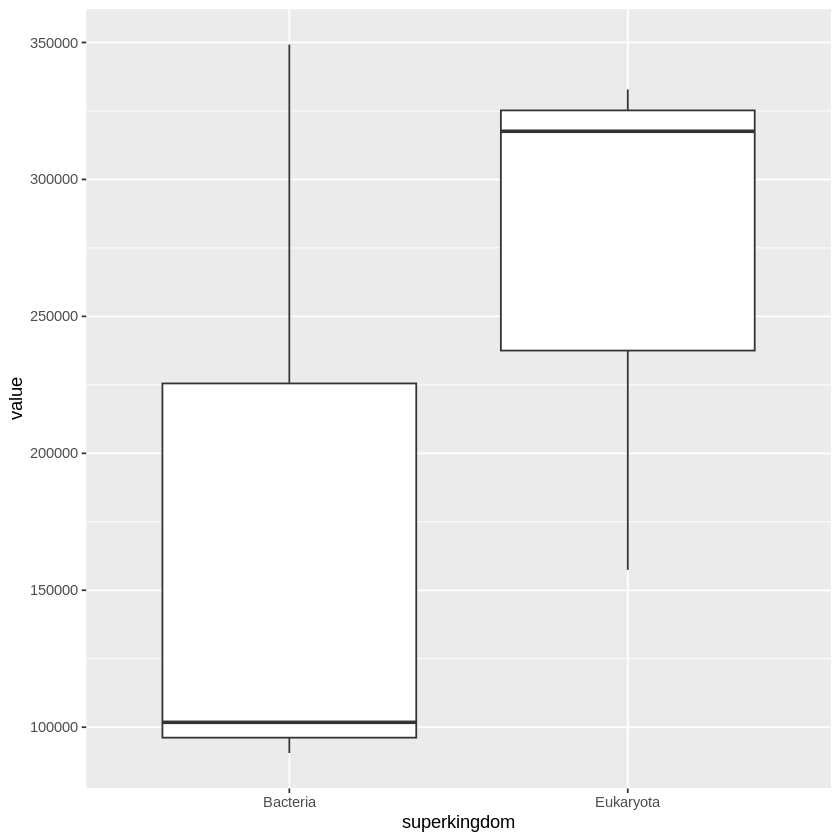


	Wilcoxon rank sum exact test

data:  spk1 and spk2
W = 2, p-value = 0.4
alternative hypothesis: true location shift is not equal to 0


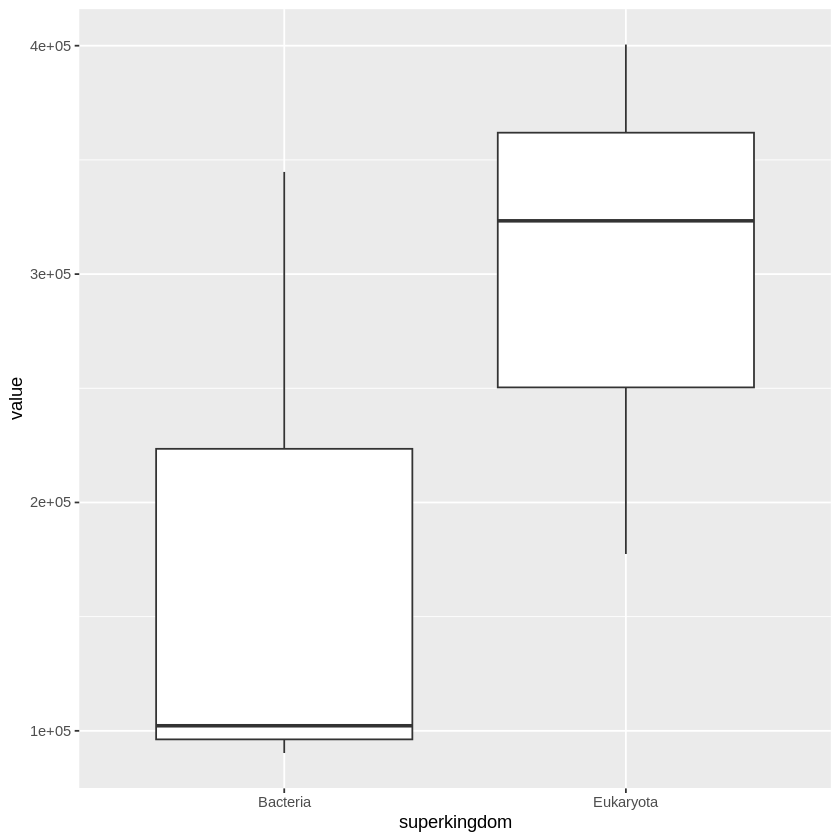

In [57]:
wilcoxon_test(dfsum, "EN0.2", "Bacteria", "Eukaryota")

message("")
message("---------------------")
message("---------------------")
message("")

wilcoxon_test(dfsum, "OP0.2", "Bacteria", "Eukaryota")

message("")
message("---------------------")
message("---------------------")
message("")

wilcoxon_test(dfsum, "OP1.2", "Bacteria", "Eukaryota")

message("")
message("---------------------")
message("---------------------")
message("")

wilcoxon_test(dfsum, "OP5.0", "Bacteria", "Eukaryota")

message("")
message("---------------------")
message("---------------------")
message("")

wilcoxon_test(dfsum, "OP8.0", "Bacteria", "Eukaryota")

*Table*

In [4]:
# Mean and std per superkingdom and pore size
dfm <- dfsum %>% melt() %>% mutate(variable = substr(variable, 1, 5))
dfm <- dfm %>% group_by(superkingdom, variable) %>% summarise(mean = mean(value), sd = sd(value))
#dfm %>% mutate('mean ± sd' = paste(mean, "±", sd, sep = " "))
dfperc <- dfm %>% group_by(variable) %>% mutate(mean_perc = mean / sum(mean) * 100, sd_perc = sd / sum(mean) * 100)
final_df <- dfperc %>% mutate('perc ± sd' = paste(format(round(mean_perc,2), nsmall=2), "±", format(round(sd_perc,2), nsmall=2), sep = " "))
final_df

Using superkingdom as id variables

`summarise()` has grouped output by 'superkingdom'. You can override using the
`.groups` argument.


superkingdom,variable,mean,sd,mean_perc,sd_perc,perc ± sd
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Archaea,EN0.2,9602.000,1227.1703,1.6409636,0.20972108,1.64 ± 0.21
Archaea,OP0.2,10285.333,759.5639,1.7577440,0.12980803,1.76 ± 0.13
Archaea,OP1.2,3740.667,1543.1793,0.6392728,0.26372642,0.64 ± 0.26
Archaea,OP5.0,2058.000,580.2792,0.3517083,0.09916862,0.35 ± 0.10
Archaea,OP8.0,1881.333,316.7417,0.3215163,0.05413056,0.32 ± 0.05
Bacteria,EN0.2,441435.000,36416.5069,75.4404044,6.22351197,75.44 ± 6.22
Bacteria,OP0.2,415937.333,5213.3550,71.0829015,0.89095248,71.08 ± 0.89
Bacteria,OP1.2,252140.000,111762.4794,43.0902479,19.09999580,43.09 ± 19.10
Bacteria,OP5.0,180540.333,146219.3480,30.8540006,24.98860930,30.85 ± 24.99


In [ ]:
comp_abunperc_change <- function(perc_1, sd_1, perc_2, sd_2) {
	values <- c(perc_2 + sd_2, perc_2, perc_2 - sd_2) - c(perc_1 + sd_1, perc_1, perc_1 - sd_1)
	print(values)
	print(paste(mean(values), "±", sd(values)))
}

comp_abunperc_change(46.02, 16.60, 43.96, 15.33)

[1] -3.33 -2.06 -0.79
[1] "-2.06 ± 1.27"


*Fisher test: Superkingdom*

In [156]:
gt_spk <- function(data, spk, cols1, cols2) {
	data$superkingdom[is.na(data$superkingdom)] <- "Unknown"
	data$superkingdom[data$superkingdom != spk] <- "Other"

	contigency <- data[,c(1, 9:23)] %>% melt() %>% ungroup() %>% mutate(cat = substr(variable, 1, 5)) %>% filter(cat %in% c(cols1, cols2)) %>% group_by(cat, superkingdom) %>% summarize(count = sum(value))
	contigency <- contigency %>% pivot_wider(names_from = cat, values_from = count)

	# Adapt matrix
	contigency <- as.matrix(contigency)
	rownames(contigency) <- contigency[,1]
	contigency <- contigency[,-1]
	class(contigency) <- "numeric"

	# Order
	contigency <- contigency[,c(cols1, cols2)]

	# Table
	print(contigency)

	# Run test
	print(fisher.test(contigency))

	print(GTest(contigency, correct = "yates"))
	print(GTest(contigency, correct = "yates")$observed)
	print(GTest(contigency, correct = "yates")$expected)

	# CramerV
	print(paste("Cramer's V: ",CramerV(contigency, ci=TRUE))) # 0 to 1: larger the more associated

	# Phi coef
	print(paste("Phi: ", phi(contigency))) # -1 to 1: Like a correlation
}

In [157]:
# Fisher Exact test: Bacteria - GP

gt_spk(df, "Bacteria", "EN0.2", "OP8.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_spk(df, "Bacteria", "EN0.2", "OP5.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_spk(df, "Bacteria", "EN0.2", "OP1.2")

message("")
message("---------------------")
message("---------------------")
message("")

gt_spk(df, "Bacteria", "EN0.2", "OP0.2")

Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


           EN0.2   OP8.0
Bacteria 1324305  537268
Other     431127 1218164

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 6.931206 6.998383
sample estimates:
odds ratio 
  6.964619 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 734749, X-squared df = 1, p-value < 2.2e-16

             EN0.2     OP8.0
Bacteria 1324304.5  537268.5
Other     431127.5 1218163.5
            EN0.2    OP8.0
Bacteria 930786.5 930786.5
Other    824645.5 824645.5
[1] "Cramer's V:  0.449165581145368"
[1] "Phi:  0.45"




---------------------

---------------------



Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


           EN0.2   OP5.0
Bacteria 1324305  541621
Other     431127 1213811

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 6.850883 6.916888
sample estimates:
odds ratio 
  6.883958 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 726597, X-squared df = 1, p-value < 2.2e-16

             EN0.2     OP5.0
Bacteria 1324304.5  541621.5
Other     431127.5 1213810.5
          EN0.2  OP5.0
Bacteria 932963 932963
Other    822469 822469
[1] "Cramer's V:  0.446749917541055"
[1] "Phi:  0.45"




---------------------

---------------------



Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


           EN0.2  OP1.2
Bacteria 1324305 756420
Other     431127 999012

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 4.038564 4.075229
sample estimates:
odds ratio 
  4.056606 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 388806, X-squared df = 1, p-value < 2.2e-16

             EN0.2    OP1.2
Bacteria 1324304.5 756420.5
Other     431127.5 999011.5
             EN0.2     OP1.2
Bacteria 1040362.5 1040362.5
Other     715069.5  715069.5
[1] "Cramer's V:  0.329203110336281"
[1] "Phi:  0.33"




---------------------

---------------------



Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


           EN0.2   OP0.2
Bacteria 1324305 1247812
Other     431127  507620

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.243661 1.255568
sample estimates:
odds ratio 
  1.249597 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 8514.8, X-squared df = 1, p-value < 2.2e-16

             EN0.2     OP0.2
Bacteria 1324304.5 1247812.5
Other     431127.5  507619.5
             EN0.2     OP0.2
Bacteria 1286058.5 1286058.5
Other     469373.5  469373.5
[1] "Cramer's V:  0.0492268507501025"
[1] "Phi:  0.05"


In [158]:
# Fisher Exact test: Bacteria - 0.2

gt_spk(df, "Bacteria", "OP0.2", "OP8.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_spk(df, "Bacteria", "OP0.2", "OP5.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_spk(df, "Bacteria", "OP0.2", "OP1.2")

Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


           OP0.2   OP8.0
Bacteria 1247812  537268
Other     507620 1218164

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 5.548239 5.598521
sample estimates:
odds ratio 
  5.573473 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 592244, X-squared df = 1, p-value < 2.2e-16

             OP0.2     OP8.0
Bacteria 1247811.5  537268.5
Other     507620.5 1218163.5
          OP0.2  OP8.0
Bacteria 892540 892540
Other    862892 862892
[1] "Cramer's V:  0.404826482799479"
[1] "Phi:  0.4"




---------------------

---------------------



Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


           OP0.2   OP5.0
Bacteria 1247812  541621
Other     507620 1213811

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 5.483166 5.533225
sample estimates:
odds ratio 
  5.508921 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 584852, X-squared df = 1, p-value < 2.2e-16

             OP0.2     OP5.0
Bacteria 1247811.5  541621.5
Other     507620.5 1213810.5
            OP0.2    OP5.0
Bacteria 894716.5 894716.5
Other    860715.5 860715.5
[1] "Cramer's V:  0.402364491609549"
[1] "Phi:  0.4"




---------------------

---------------------



Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


           OP0.2  OP1.2
Bacteria 1247812 756420
Other     507620 999012

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 3.232111 3.260993
sample estimates:
odds ratio 
  3.246502 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 284952, X-squared df = 1, p-value < 2.2e-16

             OP0.2    OP1.2
Bacteria 1247811.5 756420.5
Other     507620.5 999011.5
           OP0.2   OP1.2
Bacteria 1002116 1002116
Other     753316  753316
[1] "Cramer's V:  0.282781173327683"
[1] "Phi:  0.28"


In [159]:
# Fisher Exact test: Bacteria - 1.2

gt_spk(df, "Bacteria", "OP1.2", "OP8.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_spk(df, "Bacteria", "OP1.2", "OP5.0")

Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


          OP1.2   OP8.0
Bacteria 756420  537268
Other    999012 1218164

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.709254 1.724381
sample estimates:
odds ratio 
  1.716784 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 59001, X-squared df = 1, p-value < 2.2e-16

            OP1.2     OP8.0
Bacteria 756419.5  537268.5
Other    999012.5 1218163.5
           OP1.2   OP8.0
Bacteria  646844  646844
Other    1108588 1108588
[1] "Cramer's V:  0.129398898398666"
[1] "Phi:  0.13"




---------------------

---------------------



Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


          OP1.2   OP5.0
Bacteria 756420  541621
Other    999012 1213811

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.689469 1.704281
sample estimates:
odds ratio 
  1.696902 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 56592, X-squared df = 1, p-value < 2.2e-16

            OP1.2     OP5.0
Bacteria 756419.5  541621.5
Other    999012.5 1213810.5
             OP1.2     OP5.0
Bacteria  649020.5  649020.5
Other    1106411.5 1106411.5
[1] "Cramer's V:  0.126740294397387"
[1] "Phi:  0.13"


In [160]:
# Fisher Exact test: Bacteria - 5.0
gt_spk(df, "Bacteria", "OP5.0", "OP8.0")

Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


           OP5.0   OP8.0
Bacteria  541621  537268
Other    1213811 1218164

	Fisher's Exact Test for Count Data

data:  contigency
p-value = 4.799e-07
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.007153 1.016325
sample estimates:
odds ratio 
  1.011719 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 25.343, X-squared df = 1, p-value = 4.799e-07

             OP5.0     OP8.0
Bacteria  541620.5  537268.5
Other    1213811.5 1218163.5
             OP5.0     OP8.0
Bacteria  539444.5  539444.5
Other    1215987.5 1215987.5
[1] "Cramer's V:  0.00268732833582128"
[1] "Phi:  0"


In [161]:
# Fisher Exact test: Eukaryota - GP

gt_spk(df, "Eukaryota", "EN0.2", "OP8.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_spk(df, "Eukaryota", "EN0.2", "OP5.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_spk(df, "Eukaryota", "EN0.2", "OP1.2")

message("")
message("---------------------")
message("---------------------")
message("")

gt_spk(df, "Eukaryota", "EN0.2", "OP0.2")

Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


            EN0.2  OP8.0
Eukaryota  369866 901278
Other     1385566 854154

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.2518144 0.2541487
sample estimates:
odds ratio 
 0.2529883 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 356428, X-squared df = 1, p-value < 2.2e-16

              EN0.2    OP8.0
Eukaryota  369866.5 901277.5
Other     1385565.5 854154.5
            EN0.2   OP8.0
Eukaryota  635572  635572
Other     1119860 1119860
[1] "Cramer's V:  0.314946739853478"
[1] "Phi:  -0.31"




---------------------

---------------------



Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


            EN0.2  OP5.0
Eukaryota  369866 807886
Other     1385566 947546

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.3115925 0.3145735
sample estimates:
odds ratio 
  0.313089 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 249608, X-squared df = 1, p-value < 2.2e-16

              EN0.2    OP5.0
Eukaryota  369866.5 807885.5
Other     1385565.5 947546.5
            EN0.2   OP5.0
Eukaryota  588876  588876
Other     1166556 1166556
[1] "Cramer's V:  0.264240402333296"
[1] "Phi:  -0.26"




---------------------

---------------------



Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


            EN0.2  OP1.2
Eukaryota  369866 771633
Other     1385566 983799

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.3387533 0.3419607
sample estimates:
odds ratio 
 0.3403399 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 212938, X-squared df = 1, p-value < 2.2e-16

              EN0.2    OP1.2
Eukaryota  369866.5 771632.5
Other     1385565.5 983799.5
              EN0.2     OP1.2
Eukaryota  570749.5  570749.5
Other     1184682.5 1184682.5
[1] "Cramer's V:  0.244298336683973"
[1] "Phi:  -0.24"




---------------------

---------------------



Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


            EN0.2   OP0.2
Eukaryota  369866  338013
Other     1385566 1417419

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.113587 1.125220
sample estimates:
odds ratio 
  1.119391 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 1795.7, X-squared df = 1, p-value < 2.2e-16

              EN0.2     OP0.2
Eukaryota  369865.5  338013.5
Other     1385566.5 1417418.5
              EN0.2     OP0.2
Eukaryota  353939.5  353939.5
Other     1401492.5 1401492.5
[1] "Cramer's V:  0.0226131175541953"
[1] "Phi:  0.02"


In [162]:
# Fisher Exact test: Eukaryota - 0.2

gt_spk(df, "Eukaryota", "OP0.2", "OP8.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_spk(df, "Eukaryota", "OP0.2", "OP5.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_spk(df, "Eukaryota", "OP0.2", "OP1.2")

Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


            OP0.2  OP8.0
Eukaryota  338013 901278
Other     1417419 854154

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.2249367 0.2271167
sample estimates:
odds ratio 
  0.226009 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 406777, X-squared df = 1, p-value < 2.2e-16

              OP0.2    OP8.0
Eukaryota  338013.5 901277.5
Other     1417418.5 854154.5
              OP0.2     OP8.0
Eukaryota  619645.5  619645.5
Other     1135786.5 1135786.5
[1] "Cramer's V:  0.335708833609725"
[1] "Phi:  -0.34"




---------------------

---------------------



Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


            OP0.2  OP5.0
Eukaryota  338013 807886
Other     1417419 947546

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.2783345 0.2810557
sample estimates:
odds ratio 
 0.2796784 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 292447, X-squared df = 1, p-value < 2.2e-16

              OP0.2    OP5.0
Eukaryota  338013.5 807885.5
Other     1417418.5 947546.5
              OP0.2     OP5.0
Eukaryota  572949.5  572949.5
Other     1182482.5 1182482.5
[1] "Cramer's V:  0.285426939650707"
[1] "Phi:  -0.29"




---------------------

---------------------



Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


            OP0.2  OP1.2
Eukaryota  338013 771633
Other     1417419 983799

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.3025551 0.3054775
sample estimates:
odds ratio 
 0.3040402 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 252781, X-squared df = 1, p-value < 2.2e-16

              OP0.2    OP1.2
Eukaryota  338013.5 771632.5
Other     1417418.5 983799.5
            OP0.2   OP1.2
Eukaryota  554823  554823
Other     1200609 1200609
[1] "Cramer's V:  0.265644778580064"
[1] "Phi:  -0.27"


In [163]:
# Fisher Exact test: Eukaryota - 1.2

gt_spk(df, "Eukaryota", "OP1.2", "OP8.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_spk(df, "Eukaryota", "OP1.2", "OP5.0")

Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


           OP1.2  OP8.0
Eukaryota 771633 901278
Other     983799 854154

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.7402191 0.7464892
sample estimates:
odds ratio 
 0.7433421 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 19209, X-squared df = 1, p-value < 2.2e-16

             OP1.2    OP8.0
Eukaryota 771633.5 901277.5
Other     983798.5 854154.5
             OP1.2    OP8.0
Eukaryota 836455.5 836455.5
Other     918976.5 918976.5
[1] "Cramer's V:  0.0739353533739032"
[1] "Phi:  -0.07"




---------------------

---------------------



Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


           OP1.2  OP5.0
Eukaryota 771633 807886
Other     983799 947546

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.9160518 0.9237892
sample estimates:
odds ratio 
 0.9199303 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 1512.6, X-squared df = 1, p-value < 2.2e-16

             OP1.2    OP5.0
Eukaryota 771633.5 807885.5
Other     983798.5 947546.5
             OP1.2    OP5.0
Eukaryota 789759.5 789759.5
Other     965672.5 965672.5
[1] "Cramer's V:  0.0207563790939492"
[1] "Phi:  -0.02"


In [164]:
# Fisher Exact test: Eukaryota - 5.0
gt_spk(df, "Eukaryota", "OP5.0", "OP8.0")

Using superkingdom as id variables

`summarise()` has grouped output by 'cat'. You can
override using the `.groups` argument.


           OP5.0  OP8.0
Eukaryota 807886 901278
Other     947546 854154

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.8046607 0.8114458
sample estimates:
odds ratio 
 0.8080361 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 9948.6, X-squared df = 1, p-value < 2.2e-16

             OP5.0    OP8.0
Eukaryota 807886.5 901277.5
Other     947545.5 854154.5
           OP5.0  OP8.0
Eukaryota 854582 854582
Other     900850 900850
[1] "Cramer's V:  0.0532202080933669"
[1] "Phi:  -0.05"


*Bar plot*

Using phylum as id variables



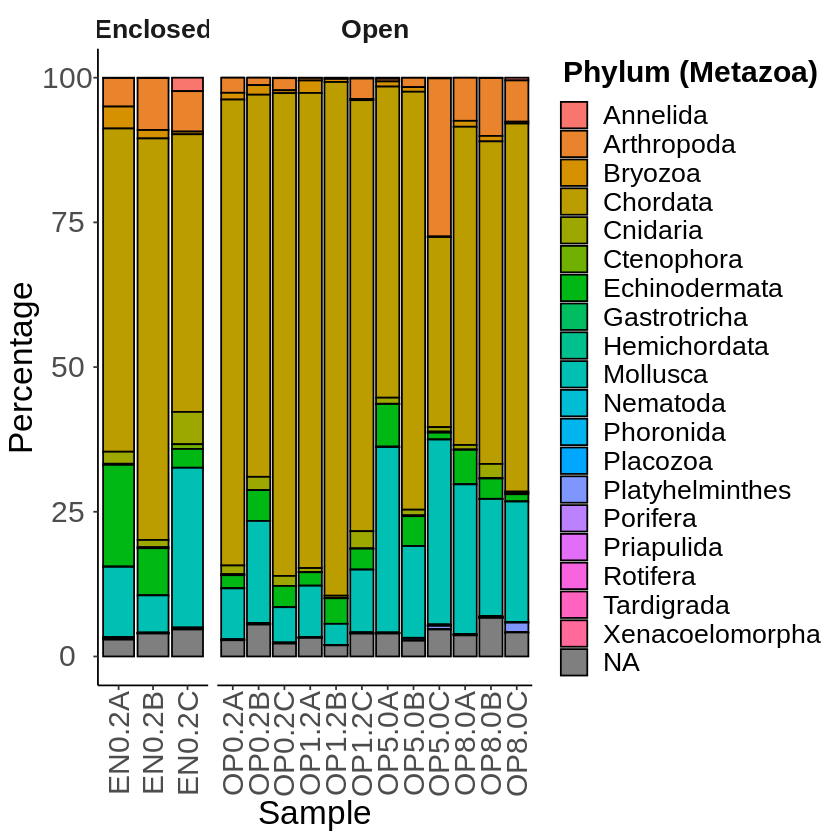

In [ ]:
# Metazoan phyla between pore sizes
dfsum_metazoa <- df[,c(2,3,9:23)] %>% filter(kingdom == "Metazoa") %>% group_by(phylum) %>% summarise_if(is.numeric, sum, na.rm=F)
dfsum_metazoa <- dfsum_metazoa %>% melt() %>% group_by(variable) %>% mutate(perc = value / sum(value) * 100) %>% ungroup()

dfsum_metazoa <- dfsum_metazoa %>% mutate(type = ifelse(grepl("EN", variable), "Enclosed", "Open"))

p <- dfsum_metazoa %>% ggplot() + geom_col(aes(x=variable, y=perc, fill=phylum), color="black") +
labs(x="Sample", y="Percentage", fill="Phylum (Metazoa)") +
facet_wrap(~type, scales="free_x") +
theme_classic() %+replace% theme(axis.text.x = element_text(angle = 90, size=18),
								 axis.text.y = element_text(size=18),
								 axis.title = element_text(size=20),
								 strip.text.x = element_text(size = 16, face="bold"),
								 strip.background = element_blank(),
								 legend.title = element_text(size=18, face="bold"),
								 legend.text = element_text(size=16))

gt = ggplot_gtable(ggplot_build(p))
gt$widths[5] = 0.35*gt$widths[5]

#png(file="bars.metazoa_phyla.rarefied.png", width=2300, height=2000, res=300)
grid.draw(gt)
#dev.off()

---------------------

*Metazoa Difference*

In [8]:
dfperc_metazoa <- dfsum_metazoa %>% mutate(variable = substr(variable, 1, 5)) %>% select(-value, -type) %>% group_by(phylum, variable) %>% summarize(mean = mean(perc)) %>% pivot_wider(names_from = variable, values_from = mean)

# Compute differences
diff_80_02 <- dfperc_metazoa %>% mutate(diff_80_02 = format(round(OP8.0 - OP0.2, 4), nsmall=4)) %>% select(phylum, diff_80_02) %>% filter(diff_80_02 > 0)
diff_80_GP <- dfperc_metazoa %>% mutate(diff_80_GP = format(round(OP8.0 - EN0.2, 4), nsmall=4)) %>% select(phylum, diff_80_GP) %>% filter(diff_80_GP > 0)
diff_80_12 <- dfperc_metazoa %>% mutate(diff_80_12 = format(round(OP8.0 - OP1.2, 4), nsmall=4)) %>% select(phylum, diff_80_12) %>% filter(diff_80_12 > 0)

diff_50_02 <- dfperc_metazoa %>% mutate(diff_50_02 = format(round(OP5.0 - OP0.2, 4), nsmall=4)) %>% select(phylum, diff_50_02) %>% filter(diff_50_02 > 0)
diff_50_GP <- dfperc_metazoa %>% mutate(diff_50_GP = format(round(OP5.0 - EN0.2, 4), nsmall=4)) %>% select(phylum, diff_50_GP) %>% filter(diff_50_GP > 0)
diff_50_12 <- dfperc_metazoa %>% mutate(diff_50_12 = format(round(OP5.0 - OP1.2, 4), nsmall=4)) %>% select(phylum, diff_50_12) %>% filter(diff_50_12 > 0)

`summarise()` has grouped output by 'phylum'. You can override using the `.groups` argument.


In [9]:
# Merge all
lst <- list(diff_80_GP, diff_80_02, diff_80_12, diff_50_GP, diff_50_02, diff_50_12)
dfup_metazoa <- Reduce(function(...) merge(..., all=T), lst)
dfup_metazoa

phylum,diff_80_GP,diff_80_02,diff_80_12,diff_50_GP,diff_50_02,diff_50_12
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Annelida,NA,0.1551,0.1031,NA,0.0798,0.0278
Arthropoda,1.2275,6.1918,6.8101,2.8344,7.7986,8.4170
Chordata,0.3738,NA,NA,NA,NA,NA
Ctenophora,NA,0.0518,0.0745,NA,0.0613,0.0840
Echinodermata,NA,NA,0.1226,NA,0.8080,1.1142
Gastrotricha,NA,0.0000,0.0000,0.0073,0.0283,0.0283
Hemichordata,0.0092,0.0092,0.0092,0.0000,0.0000,0.0000
Mollusca,6.9181,11.4603,14.5194,11.2308,15.7731,18.8322
Nematoda,NA,NA,0.0058,NA,NA,6e-04


*Metazoan abudance increase*

In [ ]:
# [X] Odds ratio test: Kingdom
# [X] Wilcoxon test on Merged pore sizes (1: Spk between group // 2: King between groups - Low vs High division) -> 5 + 4 tests
# [X] Averages and increases between groups per metazoan phyla -> 17 rows * 2 groups

In [72]:
# Obtain table
phyla <- df %>% filter(kingdom == "Metazoa") %>% select(phylum) %>% unique()
df[,c(3,9:23)] %>% filter(phylum %in% phyla$phylum) %>% group_by(phylum) %>% summarise_if(is.numeric, sum, na.rm=F)

phylum,OP0.2A,OP0.2B,OP0.2C,OP1.2A,OP1.2B,OP1.2C,OP5.0A,OP5.0B,OP5.0C,OP8.0A,OP8.0B,OP8.0C,EN0.2A,EN0.2B,EN0.2C
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Annelida,0,0,4,6,8,10,41,9,18,4,14,115,1,3,20
Arthropoda,56,14,93,55,32,228,104,544,4114,1929,2162,1725,78,351,60
Bryozoa,25,18,22,271,96,14,199,271,15,266,204,79,60,57,4
Chordata,1726,719,3716,10333,16180,4827,12024,24517,4947,14260,12053,15393,884,2716,412
Cnidaria,32,25,77,85,78,193,235,332,116,200,528,64,33,49,48
Ctenophora,4,0,0,7,3,3,9,49,28,19,17,46,3,7,7
Echinodermata,49,58,164,293,806,235,1646,1753,180,1548,759,306,278,319,28
Gastrotricha,0,0,0,0,0,0,19,0,0,0,0,0,1,0,0
Hemichordata,0,0,0,0,0,0,0,0,0,0,6,0,0,0,0


In [95]:
# Obtain table
phyla <- df %>% filter(kingdom == "Metazoa") %>% select(phylum) %>% unique()

phyla_df <- df[,c(3,9:23)] %>% filter(phylum %in% phyla$phylum) %>% group_by(phylum) %>% summarise_if(is.numeric, sum, na.rm=F) %>% melt() %>% mutate(cat = substr(variable, 1,5)) %>% mutate(porecat = ifelse(cat %in% c('EN0.2','OP0.2','OP1.2'), 'Low', 'High'))

Using phylum as id variables



In [97]:
# Sum table
phyla_df %>% group_by(phylum, porecat) %>% summarize(value = sum(value)) %>% ungroup() %>% pivot_wider(names_from = porecat, values_from = value) %>% select(phylum, Low, High) %>% mutate(High_Increase = High - Low)

`summarise()` has grouped output by 'phylum'. You can override using the `.groups` argument.


phylum,Low,High,High_Increase
<chr>,<int>,<int>,<int>
Annelida,52,201,149
Arthropoda,967,10578,9611
Bryozoa,567,1034,467
Chordata,41513,83194,41681
Cnidaria,620,1475,855
Ctenophora,34,168,134
Echinodermata,2230,6192,3962
Gastrotricha,1,19,18
Hemichordata,0,6,6


In [98]:
# Mean table
phyla_df %>% group_by(phylum, porecat) %>% summarize(value = round(mean(value),2)) %>% ungroup() %>% pivot_wider(names_from = porecat, values_from = value) %>% select(phylum, Low, High) %>% mutate(High_Increase = High - Low)

`summarise()` has grouped output by 'phylum'. You can override using the `.groups` argument.


phylum,Low,High,High_Increase
<chr>,<dbl>,<dbl>,<dbl>
Annelida,5.78,33.50,27.72
Arthropoda,107.44,1763.00,1655.56
Bryozoa,63.00,172.33,109.33
Chordata,4612.56,13865.67,9253.11
Cnidaria,68.89,245.83,176.94
Ctenophora,3.78,28.00,24.22
Echinodermata,247.78,1032.00,784.22
Gastrotricha,0.11,3.17,3.06
Hemichordata,0.00,1.00,1.00


*Wilcoxon test: Kingdom*

In [50]:
wilcoxon_test_kingdom_groups <- function(data, k) {
	# Rename kingdoms
	data$kingdom[is.na(data$kingdom)] <- "Unknown"
	# Filter data
	data <- data %>% melt() %>% mutate(variable = substr(variable, 1, 5)) %>% mutate(porecat = ifelse(variable %in% c('EN0.2','OP0.2','OP1.2'), 'Low', 'High')) %>% filter(kingdom == k)
	# Split data
	k1 <- data$value[data$porecat == "Low"]
	k2 <- data$value[data$porecat == "High"]
	# Print
	print(k1)
	print(k2)
	# Mean and sd
	print(paste(round(mean(k1),2), "±", round(sd(k1),2)))
	print(paste(round(mean(k2),2), "±", round(sd(k2),2)))
	# Wilcoxon test
	res <- wilcox.test(k1, k2)
	# Return results
	return(res)
}

In [65]:
dfsum_k <- df[,c(2,9:23)] %>% group_by(kingdom) %>% summarise_if(is.numeric, sum, na.rm=F)
dfsum_k

kingdom,OP0.2A,OP0.2B,OP0.2C,OP1.2A,OP1.2B,OP1.2C,OP5.0A,OP5.0B,OP5.0C,OP8.0A,OP8.0B,OP8.0C,EN0.2A,EN0.2B,EN0.2C
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Fungi,16,28,50,206,117,70,188,311,239,271,314,391,24,55,16
Metazoa,2144,1089,4455,12588,18230,6482,22369,33951,15062,25936,21627,24207,1583,3915,859
Viridiplantae,102212,111024,97051,225014,271802,127065,18222,12487,8974,18348,10104,6393,93845,115924,75630
NA,480772,473003,483588,347336,294995,451527,544365,538395,560869,540589,553099,554153,489692,465250,508639


In [66]:
# Wilcoxon between groups
wil_meta <- wilcoxon_test_kingdom_groups(dfsum_k, "Metazoa")
wil_meta

message("")
message("---------------------")
message("---------------------")
message("")

wil_plan <- wilcoxon_test_kingdom_groups(dfsum_k, "Viridiplantae")
wil_plan

message("")
message("---------------------")
message("---------------------")
message("")

wil_fung <- wilcoxon_test_kingdom_groups(dfsum_k, "Fungi")
wil_fung

message("")
message("---------------------")
message("---------------------")
message("")

wil_unkn <- wilcoxon_test_kingdom_groups(dfsum_k, "Unknown")
wil_unkn

Using kingdom as id variables



[1]  2144  1089  4455 12588 18230  6482  1583  3915   859
[1] 22369 33951 15062 25936 21627 24207
[1] "5705 ± 5959.07"
[1] "23858.67 ± 6178.55"



	Wilcoxon rank sum exact test

data:  k1 and k2
W = 1, p-value = 0.0007992
alternative hypothesis: true location shift is not equal to 0




---------------------

---------------------



Using kingdom as id variables



[1] 102212 111024  97051 225014 271802 127065  93845 115924  75630
[1] 18222 12487  8974 18348 10104  6393
[1] "135507.44 ± 66661.84"
[1] "12421.33 ± 4947.17"


...

Warning message in wilcox.test.default(k1, k2):
“cannot compute exact p-value with ties”



	Wilcoxon rank sum test with continuity correction

data:  k1 and k2
W = 1, p-value = 0.002631
alternative hypothesis: true location shift is not equal to 0




---------------------

---------------------



Using kingdom as id variables



[1] 480772 473003 483588 347336 294995 451527 489692 465250 508639
[1] 544365 538395 560869 540589 553099 554153
[1] "443866.89 ± 72526.72"
[1] "548578.33 ± 8807.45"



	Wilcoxon rank sum exact test

data:  k1 and k2
W = 0, p-value = 0.0003996
alternative hypothesis: true location shift is not equal to 0


In [56]:
pvals <- c(wil_meta$p.value, wil_plan$p.value, wil_fung$p.value, wil_unkn$p.value)
p.adjust(pvals, method = "BH", n = length(pvals))

[1] 0.0010656011 0.0007992008 0.0026306779 0.0007992008

In [48]:
wilcoxon_test_kingdom <- function(data, pore, k1, k2) {
	# Filter data
	data <- data %>% melt() %>% mutate(variable = substr(variable, 1, 5)) %>% filter(variable == pore) %>% drop_na()
	# Split data
	k1 <- data$value[data$kingdom == k1]
	k2 <- data$value[data$kingdom == k2]
	# Print
	print(k1)
	print(k2)
	# Wilcoxon test
	res <- wilcox.test(k1, k2)
	# Return results
	return(res)
}

In [ ]:
wilcoxon_test_kingdom(dfsum_k, "EN0.2", "Metazoa", "Viridiplantae")

message("")
message("---------------------")
message("---------------------")
message("")

wilcoxon_test_kingdom(dfsum_k, "OP0.2", "Metazoa", "Viridiplantae")

message("")
message("---------------------")
message("---------------------")
message("")

wilcoxon_test_kingdom(dfsum_k, "OP1.2", "Metazoa", "Viridiplantae")

message("")
message("---------------------")
message("---------------------")
message("")

wilcoxon_test_kingdom(dfsum_k, "OP5.0", "Metazoa", "Viridiplantae")

message("")
message("---------------------")
message("---------------------")
message("")

wilcoxon_test_kingdom(dfsum_k, "OP8.0", "Metazoa", "Viridiplantae")

Using kingdom as id variables



[1] 1583 3915  859
[1]  93845 115924  75630



	Wilcoxon rank sum exact test

data:  k1 and k2
W = 0, p-value = 0.1
alternative hypothesis: true location shift is not equal to 0




---------------------

---------------------



Using kingdom as id variables



[1] 2144 1089 4455
[1] 102212 111024  97051


...

[1] 22369 33951 15062
[1] 18222 12487  8974



	Wilcoxon rank sum exact test

data:  k1 and k2
W = 8, p-value = 0.2
alternative hypothesis: true location shift is not equal to 0




---------------------

---------------------



Using kingdom as id variables



[1] 25936 21627 24207
[1] 18348 10104  6393



	Wilcoxon rank sum exact test

data:  k1 and k2
W = 9, p-value = 0.1
alternative hypothesis: true location shift is not equal to 0


In [12]:
df %>% select(c(2,9:23)) %>% melt() %>% ungroup() %>% filter(kingdom %in% c('Metazoa','Viridiplantae')) %>% mutate(cat = substr(variable, 1, 5)) %>% group_by(cat, kingdom) %>% summarize(count = sum(value))

Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


cat,kingdom,count
<chr>,<chr>,<int>
EN0.2,Metazoa,6357
EN0.2,Viridiplantae,285399
OP0.2,Metazoa,7688
OP0.2,Viridiplantae,310287
OP1.2,Metazoa,37300
OP1.2,Viridiplantae,623881
OP5.0,Metazoa,71382
OP5.0,Viridiplantae,39683
OP8.0,Metazoa,71770


In [103]:
gt_k <- function(data, k, cols1, cols2) {
	data$kingdom[is.na(data$kingdom)] <- "Unknown"
	data$kingdom[data$kingdom != k] <- "Other"

	contigency <- data[,c(2, 9:23)] %>% melt() %>% ungroup() %>% mutate(cat = substr(variable, 1, 5)) %>% filter(cat %in% c(cols1, cols2)) %>% group_by(cat, kingdom) %>% summarize(count = sum(value))
	contigency <- contigency %>% pivot_wider(names_from = cat, values_from = count)

	# Adapt matrix
	contigency <- as.matrix(contigency)
	rownames(contigency) <- contigency[,1]
	contigency <- contigency[,-1]
	class(contigency) <- "numeric"

	# Order
	contigency <- contigency[c(k,"Other"),c(cols1, cols2)]

	# Table
	print(contigency)

	# Run test
	print(fisher.test(contigency))

	print(GTest(contigency, correct = "yates"))
	print(GTest(contigency, correct = "yates")$observed)
	print(GTest(contigency, correct = "yates")$expected)

	# CramerV
	print(paste("Cramer's V: ",CramerV(contigency, ci=TRUE))) # 0 to 1: larger the more associated

	# Phi coef
	print(paste("Phi: ", phi(contigency))) # -1 to 1: Like a correlation
}

In [104]:
# Fisher Exact test: Viridiplantae - GP

gt_k(df, "Viridiplantae", "EN0.2", "OP8.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_k(df, "Viridiplantae", "EN0.2", "OP5.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_k(df, "Viridiplantae", "EN0.2", "OP1.2")

message("")
message("---------------------")
message("---------------------")
message("")

gt_k(df, "Viridiplantae", "EN0.2", "OP0.2")

Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


                EN0.2   OP8.0
Viridiplantae  285399   34845
Other         1470033 1720587

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 9.476064 9.692164
sample estimates:
odds ratio 
  9.586041 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 243308, X-squared df = 1, p-value < 2.2e-16

                  EN0.2     OP8.0
Viridiplantae  285398.5   34845.5
Other         1470033.5 1720586.5
                EN0.2   OP8.0
Viridiplantae  160122  160122
Other         1595310 1595310
[1] "Cramer's V:  0.247869618332311"
[1] "Phi:  0.25"




---------------------

---------------------



Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


                EN0.2   OP5.0
Viridiplantae  285399   39683
Other         1470033 1715749

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 8.302681 8.483359
sample estimates:
odds ratio 
  8.393444 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 228397, X-squared df = 1, p-value < 2.2e-16

                  EN0.2     OP5.0
Viridiplantae  285398.5   39683.5
Other         1470033.5 1715748.5
                EN0.2   OP5.0
Viridiplantae  162541  162541
Other         1592891 1592891
[1] "Cramer's V:  0.241450966562387"
[1] "Phi:  0.24"




---------------------

---------------------



Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


                EN0.2   OP1.2
Viridiplantae  285399  623881
Other         1470033 1131551

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.3503603 0.3539197
sample estimates:
odds ratio 
 0.3521256 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 173248, X-squared df = 1, p-value < 2.2e-16

                  EN0.2     OP1.2
Viridiplantae  285399.5  623880.5
Other         1470032.5 1131551.5
                EN0.2   OP1.2
Viridiplantae  454640  454640
Other         1300792 1300792
[1] "Cramer's V:  0.220073541653018"
[1] "Phi:  -0.22"




---------------------

---------------------



Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


                EN0.2   OP0.2
Viridiplantae  285399  310287
Other         1470033 1445145

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.8991995 0.9092969
sample estimates:
odds ratio 
 0.9042187 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 1252.5, X-squared df = 1, p-value < 2.2e-16

                  EN0.2     OP0.2
Viridiplantae  285399.5  310286.5
Other         1470032.5 1445145.5
                EN0.2   OP0.2
Viridiplantae  297843  297843
Other         1457589 1457589
[1] "Cramer's V:  0.0188863816945651"
[1] "Phi:  -0.02"


In [105]:
# Fisher Exact test: Viridiplantae - 0.2

gt_k(df, "Viridiplantae", "OP0.2", "OP8.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_k(df, "Viridiplantae", "OP0.2", "OP5.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_k(df, "Viridiplantae", "OP0.2", "OP1.2")

Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


                OP0.2   OP8.0
Viridiplantae  310287   34845
Other         1445145 1720587

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 10.48102 10.72355
sample estimates:
odds ratio 
  10.60153 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 276600, X-squared df = 1, p-value < 2.2e-16

                  OP0.2     OP8.0
Viridiplantae  310286.5   34845.5
Other         1445145.5 1720586.5
                OP0.2   OP8.0
Viridiplantae  172566  172566
Other         1582866 1582866
[1] "Cramer's V:  0.263512047787791"
[1] "Phi:  0.26"




---------------------

---------------------



Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


                OP0.2   OP5.0
Viridiplantae  310287   39683
Other         1445145 1715749

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 9.182545 9.381299
sample estimates:
odds ratio 
  9.282623 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 260894, X-squared df = 1, p-value < 2.2e-16

                  OP0.2     OP5.0
Viridiplantae  310286.5   39683.5
Other         1445145.5 1715748.5
                OP0.2   OP5.0
Viridiplantae  174985  174985
Other         1580447 1580447
[1] "Cramer's V:  0.257284626795883"
[1] "Phi:  0.26"




---------------------

---------------------



Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


                OP0.2   OP1.2
Viridiplantae  310287  623881
Other         1445145 1131551

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.3874918 0.3913506
sample estimates:
odds ratio 
 0.3894251 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 145603, X-squared df = 1, p-value < 2.2e-16

                  OP0.2     OP1.2
Viridiplantae  310287.5  623880.5
Other         1445144.5 1131551.5
                OP0.2   OP1.2
Viridiplantae  467084  467084
Other         1288348 1288348
[1] "Cramer's V:  0.202126688034776"
[1] "Phi:  -0.2"


In [106]:
# Fisher Exact test: Viridiplantae - 1.2

gt_k(df, "Viridiplantae", "OP1.2", "OP8.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_k(df, "Viridiplantae", "OP1.2", "OP5.0")

Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


                OP1.2   OP8.0
Viridiplantae  623881   34845
Other         1131551 1720587

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 26.89356 27.53658
sample estimates:
odds ratio 
  27.22516 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 763055, X-squared df = 1, p-value < 2.2e-16

                  OP1.2     OP8.0
Viridiplantae  623880.5   34845.5
Other         1131551.5 1720586.5
                OP1.2   OP8.0
Viridiplantae  329363  329363
Other         1426069 1426069
[1] "Cramer's V:  0.429738405518147"
[1] "Phi:  0.43"




---------------------

---------------------



Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


                OP1.2   OP5.0
Viridiplantae  623881   39683
Other         1131551 1715749

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 23.58604 24.07359
sample estimates:
odds ratio 
  23.83903 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 740116, X-squared df = 1, p-value < 2.2e-16

                  OP1.2     OP5.0
Viridiplantae  623880.5   39683.5
Other         1131551.5 1715748.5
                OP1.2   OP5.0
Viridiplantae  331782  331782
Other         1423650 1423650
[1] "Cramer's V:  0.425012833055873"
[1] "Phi:  0.43"


In [107]:
# Fisher Exact test: Viridiplantae - 5.0
gt_k(df, "Viridiplantae", "OP5.0", "OP8.0")

Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


                OP5.0   OP8.0
Viridiplantae   39683   34845
Other         1715749 1720587

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.125535 1.158838
sample estimates:
odds ratio 
  1.142054 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 320.96, X-squared df = 1, p-value < 2.2e-16

                  OP5.0     OP8.0
Viridiplantae   39682.5   34845.5
Other         1715749.5 1720586.5
                OP5.0   OP8.0
Viridiplantae   37264   37264
Other         1718168 1718168
[1] "Cramer's V:  0.00956000940734323"
[1] "Phi:  0.01"


In [108]:
# Fisher Exact test: Metazoa - GP

gt_k(df, "Metazoa", "EN0.2", "OP8.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_k(df, "Metazoa", "EN0.2", "OP5.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_k(df, "Metazoa", "EN0.2", "OP1.2")

message("")
message("---------------------")
message("---------------------")
message("")

gt_k(df, "Metazoa", "EN0.2", "OP0.2")

Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


          EN0.2   OP8.0
Metazoa    6357   71770
Other   1749075 1683662

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.08309473 0.08750413
sample estimates:
odds ratio 
0.08527981 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 65472, X-squared df = 1, p-value < 2.2e-16

            EN0.2     OP8.0
Metazoa    6357.5   71769.5
Other   1749074.5 1683662.5
            EN0.2     OP8.0
Metazoa   39063.5   39063.5
Other   1716368.5 1716368.5
[1] "Cramer's V:  0.126311597481488"
[1] "Phi:  -0.13"




---------------------

---------------------



Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


          EN0.2   OP5.0
Metazoa    6357   71382
Other   1749075 1684050

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.08356638 0.08797088
sample estimates:
odds ratio 
0.08576228 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 64986, X-squared df = 1, p-value < 2.2e-16

            EN0.2     OP5.0
Metazoa    6357.5   71381.5
Other   1749074.5 1684050.5
            EN0.2     OP5.0
Metazoa   38869.5   38869.5
Other   1716562.5 1716562.5
[1] "Cramer's V:  0.125868216307574"
[1] "Phi:  -0.13"




---------------------

---------------------



Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


          EN0.2   OP1.2
Metazoa    6357   37300
Other   1749075 1718132

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.1629511 0.1719749
sample estimates:
odds ratio 
  0.167419 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 24559, X-squared df = 1, p-value < 2.2e-16

            EN0.2     OP1.2
Metazoa    6357.5   37299.5
Other   1749074.5 1718132.5
            EN0.2     OP1.2
Metazoa   21828.5   21828.5
Other   1733603.5 1733603.5
[1] "Cramer's V:  0.0795326745974275"
[1] "Phi:  -0.08"




---------------------

---------------------



Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


          EN0.2   OP0.2
Metazoa    6357    7688
Other   1749075 1747744

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.7990905 0.8543253
sample estimates:
odds ratio 
 0.8262451 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 126.64, X-squared df = 1, p-value < 2.2e-16

            EN0.2     OP0.2
Metazoa    6357.5    7687.5
Other   1749074.5 1747744.5
            EN0.2     OP0.2
Metazoa    7022.5    7022.5
Other   1748409.5 1748409.5
[1] "Cramer's V:  0.00600593471524942"
[1] "Phi:  -0.01"


In [110]:
# Fisher Exact test: Metazoa - 0.2

gt_k(df, "Metazoa", "OP0.2", "OP8.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_k(df, "Metazoa", "OP0.2", "OP5.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_k(df, "Metazoa", "OP0.2", "OP1.2")

Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


          OP0.2   OP8.0
Metazoa    7688   71770
Other   1747744 1683662

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.1007498 0.1056673
sample estimates:
odds ratio 
 0.1031932 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 60828, X-squared df = 1, p-value < 2.2e-16

            OP0.2     OP8.0
Metazoa    7688.5   71769.5
Other   1747743.5 1683662.5
          OP0.2   OP8.0
Metazoa   39729   39729
Other   1715703 1715703
[1] "Cramer's V:  0.122724476929772"
[1] "Phi:  -0.12"




---------------------

---------------------



Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


          OP0.2   OP5.0
Metazoa    7688   71382
Other   1747744 1684050

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.1013293 0.1062463
sample estimates:
odds ratio 
  0.103778 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 60355, X-squared df = 1, p-value < 2.2e-16

            OP0.2     OP5.0
Metazoa    7688.5   71381.5
Other   1747743.5 1684050.5
          OP0.2   OP5.0
Metazoa   39535   39535
Other   1715897 1715897
[1] "Cramer's V:  0.122273416963042"
[1] "Phi:  -0.12"




---------------------

---------------------



Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


          OP0.2   OP1.2
Metazoa    7688   37300
Other   1747744 1718132

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.1976380 0.2076907
sample estimates:
odds ratio 
 0.2026312 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 21472, X-squared df = 1, p-value < 2.2e-16

            OP0.2     OP1.2
Metazoa    7688.5   37299.5
Other   1747743.5 1718132.5
          OP0.2   OP1.2
Metazoa   22494   22494
Other   1732938 1732938
[1] "Cramer's V:  0.0749916461772819"
[1] "Phi:  -0.07"


In [111]:
# Fisher Exact test: Metazoa - 1.2

gt_k(df, "Metazoa", "OP1.2", "OP8.0")

message("")
message("---------------------")
message("---------------------")
message("")

gt_k(df, "Metazoa", "OP1.2", "OP5.0")

Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


          OP1.2   OP8.0
Metazoa   37300   71770
Other   1718132 1683662

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.5028587 0.5157915
sample estimates:
odds ratio 
 0.5092927 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 11431, X-squared df = 1, p-value < 2.2e-16

            OP1.2     OP8.0
Metazoa   37300.5   71769.5
Other   1718131.5 1683662.5
          OP1.2   OP8.0
Metazoa   54535   54535
Other   1700897 1700897
[1] "Cramer's V:  0.0565893390401862"
[1] "Phi:  -0.06"




---------------------

---------------------



Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


          OP1.2   OP5.0
Metazoa   37300   71382
Other   1718132 1684050

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.5056994 0.5187391
sample estimates:
odds ratio 
  0.512179 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 11211, X-squared df = 1, p-value < 2.2e-16

            OP1.2     OP5.0
Metazoa   37300.5   71381.5
Other   1718131.5 1684050.5
          OP1.2   OP5.0
Metazoa   54341   54341
Other   1701091 1701091
[1] "Cramer's V:  0.0560489511403431"
[1] "Phi:  -0.06"


In [112]:
# Fisher Exact test: Metazoa - 5.0

gt_k(df, "Viridiplantae", "OP5.0", "OP8.0")

Using kingdom as id variables

`summarise()` has grouped output by 'cat'. You can override using the `.groups` argument.


                OP5.0   OP8.0
Viridiplantae   39683   34845
Other         1715749 1720587

	Fisher's Exact Test for Count Data

data:  contigency
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.125535 1.158838
sample estimates:
odds ratio 
  1.142054 


	Log likelihood ratio (G-test) test of independence with Yates'
	correction

data:  contigency
G = 320.96, X-squared df = 1, p-value < 2.2e-16

                  OP5.0     OP8.0
Viridiplantae   39682.5   34845.5
Other         1715749.5 1720586.5
                OP5.0   OP8.0
Viridiplantae   37264   37264
Other         1718168 1718168
[1] "Cramer's V:  0.00956000940734323"
[1] "Phi:  0.01"


----------------

*Kruskal-Wallis: Superkingdom*

Using superkingdom as id variables



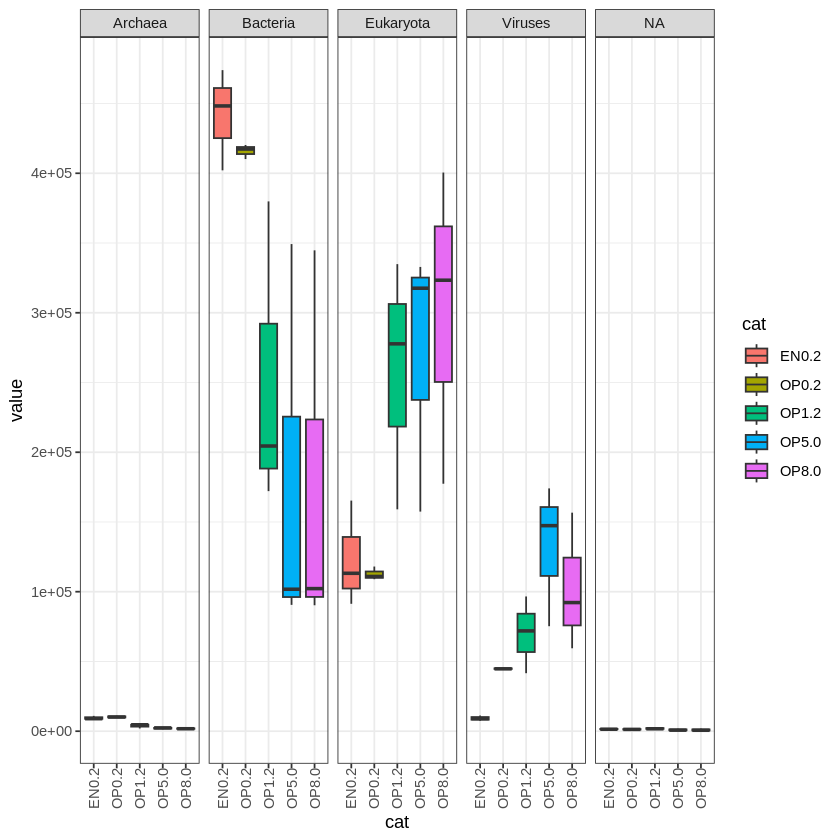

In [23]:
# Plot
dfsum %>% melt() %>% mutate(cat = substr(variable, 1, 5)) %>%
  ggplot() + geom_boxplot(aes(x=cat, y=value, fill=cat)) + facet_grid(. ~ superkingdom) +
	theme_bw() %+replace% theme(axis.text.x = element_text(angle=90))

In [ ]:
kruskal_spk <- function(data, spk, rm_repC = FALSE) {
	data$superkingdom[is.na(data$superkingdom)] <- "Unknown"
	data <- data %>% melt() %>% filter(superkingdom == spk) %>% mutate(cat = substr(variable, 1, 5))
	krus <- kruskal.test(value ~ cat, data=data)
	print(krus)
	print(pairwise.wilcox.test(data$value, data$cat, p.adjust.method = "BH"))
	return(krus)
}

In [72]:
krus_bact <- kruskal_spk(dfsum, "Bacteria")
krus_bact

message("")
message("---------------------")
message("---------------------")
message("")

krus_euka <- kruskal_spk(dfsum, "Eukaryota")
krus_euka

message("")
message("---------------------")
message("---------------------")
message("")

krus_arch <- kruskal_spk(dfsum, "Archaea")
krus_arch

message("")
message("---------------------")
message("---------------------")
message("")

krus_viru <- kruskal_spk(dfsum, "Viruses")
krus_viru

message("")
message("---------------------")
message("---------------------")
message("")

krus_unkn <- kruskal_spk(dfsum, "Unknown")
krus_unkn

Using superkingdom as id variables




	Kruskal-Wallis rank sum test

data:  value by cat
Kruskal-Wallis chi-squared = 10.833, df = 4, p-value = 0.0285


	Pairwise comparisons using Wilcoxon rank sum exact test 

data:  data$value and data$cat 

      EN0.2 OP0.2 OP1.2 OP5.0
OP0.2 0.78  -     -     -    
OP1.2 0.17  0.17  -     -    
OP5.0 0.17  0.17  0.50  -    
OP8.0 0.17  0.17  0.50  1.00 

P value adjustment method: BH 



	Kruskal-Wallis rank sum test

data:  value by cat
Kruskal-Wallis chi-squared = 10.833, df = 4, p-value = 0.0285




---------------------

---------------------



Using superkingdom as id variables




	Kruskal-Wallis rank sum test

data:  value by cat
Kruskal-Wallis chi-squared = 9.1, df = 4, p-value = 0.05865


	Pairwise comparisons using Wilcoxon rank sum exact test 

data:  data$value and data$cat 

      EN0.2 OP0.2 OP1.2 OP5.0
OP0.2 1.00  -     -     -    
OP1.2 0.33  0.25  -     -    
OP5.0 0.33  0.25  1.00  -    
OP8.0 0.25  0.25  0.88  0.88 

P value adjustment method: BH 


...


	Kruskal-Wallis rank sum test

data:  value by cat
Kruskal-Wallis chi-squared = 10.633, df = 4, p-value = 0.03101


	Pairwise comparisons using Wilcoxon rank sum exact test 

data:  data$value and data$cat 

      EN0.2 OP0.2 OP1.2 OP5.0
OP0.2 0.17  -     -     -    
OP1.2 0.17  0.70  -     -    
OP5.0 0.17  0.17  0.29  -    
OP8.0 0.17  0.17  0.70  0.70 

P value adjustment method: BH 



	Kruskal-Wallis rank sum test

data:  value by cat
Kruskal-Wallis chi-squared = 10.633, df = 4, p-value = 0.03101




---------------------

---------------------



Using superkingdom as id variables




	Kruskal-Wallis rank sum test

data:  value by cat
Kruskal-Wallis chi-squared = 3.6333, df = 4, p-value = 0.4579


	Pairwise comparisons using Wilcoxon rank sum exact test 

data:  data$value and data$cat 

      EN0.2 OP0.2 OP1.2 OP5.0
OP0.2 0.67  -     -     -    
OP1.2 0.67  0.67  -     -    
OP5.0 0.67  0.78  0.67  -    
OP8.0 0.78  0.78  0.67  1.00 

P value adjustment method: BH 



	Kruskal-Wallis rank sum test

data:  value by cat
Kruskal-Wallis chi-squared = 3.6333, df = 4, p-value = 0.4579


In [62]:
# Multiple testing correction
pvals <- c(krus_arch$p.value, krus_bact$p.value, krus_euka$p.value, krus_viru$p.value, krus_unkn$p.value)
p.adjust(pvals, method = "BH", n = length(pvals))

[1] 0.05168181 0.05168181 0.07330998 0.05168181 0.45789631

*Kruskal Wallis: Kingdom*

Using kingdom as id variables



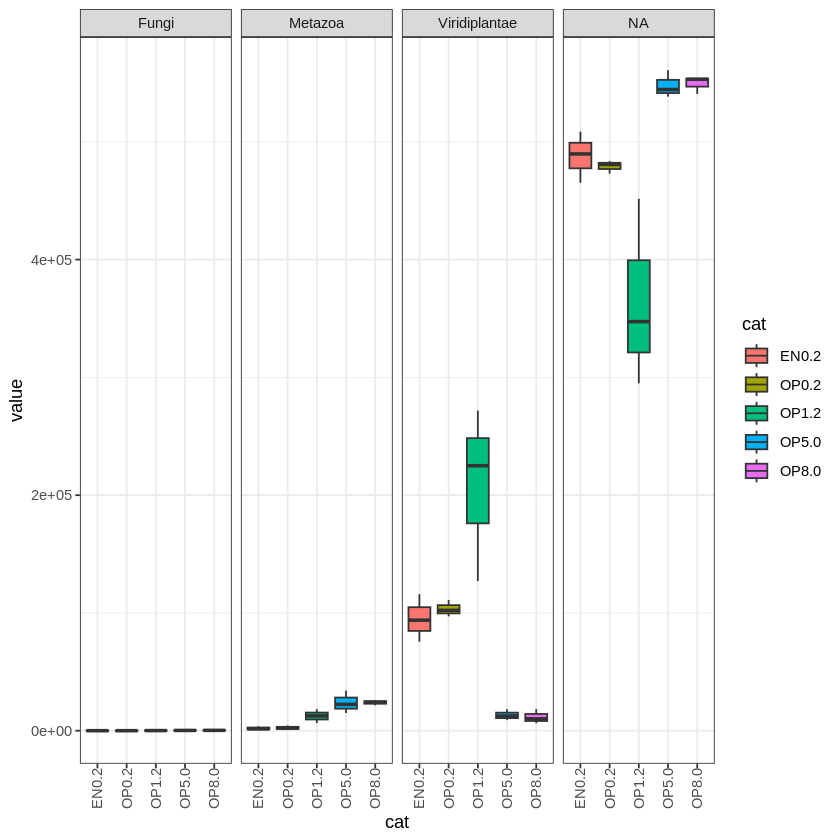

In [73]:
# Plot
dfsum_k %>% melt() %>% mutate(cat = substr(variable, 1, 5)) %>%
  ggplot() + geom_boxplot(aes(x=cat, y=value, fill=cat)) + facet_grid(. ~ kingdom) +
	theme_bw() %+replace% theme(axis.text.x = element_text(angle=90))

In [63]:
kruskal_k <- function(data, k) {
	data$kingdom[is.na(data$kingdom)] <- "Unknown"
	data <- data %>% melt() %>% filter(kingdom == k) %>% mutate(cat = substr(variable, 1, 5))
	krus <- kruskal.test(value ~ cat, data=data)
	print(krus)
	print(pairwise.wilcox.test(data$value, data$cat, p.adjust.method = "BH"))
	return(krus)
}

In [71]:
krus_meta <- kruskal_k(dfsum_k, "Metazoa")
krus_meta

message("")
message("---------------------")
message("---------------------")
message("")

krus_plan <- kruskal_k(dfsum_k, "Viridiplantae")
krus_plan

message("")
message("---------------------")
message("---------------------")
message("")

krus_fung <- kruskal_k(dfsum_k, "Fungi")
krus_fung

message("")
message("---------------------")
message("---------------------")
message("")

krus_unkn <- kruskal_k(dfsum_k, "Unknown")
krus_unkn

Using kingdom as id variables




	Kruskal-Wallis rank sum test

data:  value by cat
Kruskal-Wallis chi-squared = 11.833, df = 4, p-value = 0.01863


	Pairwise comparisons using Wilcoxon rank sum exact test 

data:  data$value and data$cat 

      EN0.2 OP0.2 OP1.2 OP5.0
OP0.2 0.78  -     -     -    
OP1.2 0.14  0.14  -     -    
OP5.0 0.14  0.14  0.25  -    
OP8.0 0.14  0.14  0.14  1.00 

P value adjustment method: BH 



	Kruskal-Wallis rank sum test

data:  value by cat
Kruskal-Wallis chi-squared = 11.833, df = 4, p-value = 0.01863




---------------------

---------------------



Using kingdom as id variables




	Kruskal-Wallis rank sum test

data:  value by cat
Kruskal-Wallis chi-squared = 12.233, df = 4, p-value = 0.0157


	Pairwise comparisons using Wilcoxon rank sum exact test 

data:  data$value and data$cat 

      EN0.2 OP0.2 OP1.2 OP5.0
OP0.2 0.78  -     -     -    
OP1.2 0.12  0.12  -     -    
OP5.0 0.12  0.12  0.12  -    
OP8.0 0.12  0.12  0.12  1.00 

P value adjustment method: BH 


...


	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  data$value and data$cat 

      EN0.2 OP0.2 OP1.2 OP5.0
OP0.2 1.00  -     -     -    
OP1.2 0.14  0.14  -     -    
OP5.0 0.14  0.14  0.22  -    
OP8.0 0.14  0.14  0.14  0.22 

P value adjustment method: BH 



	Kruskal-Wallis rank sum test

data:  value by cat
Kruskal-Wallis chi-squared = 12.28, df = 4, p-value = 0.01538




---------------------

---------------------



Using kingdom as id variables




	Kruskal-Wallis rank sum test

data:  value by cat
Kruskal-Wallis chi-squared = 12.233, df = 4, p-value = 0.0157


	Pairwise comparisons using Wilcoxon rank sum exact test 

data:  data$value and data$cat 

      EN0.2 OP0.2 OP1.2 OP5.0
OP0.2 0.78  -     -     -    
OP1.2 0.12  0.12  -     -    
OP5.0 0.12  0.12  0.12  -    
OP8.0 0.12  0.12  0.12  1.00 

P value adjustment method: BH 



	Kruskal-Wallis rank sum test

data:  value by cat
Kruskal-Wallis chi-squared = 12.233, df = 4, p-value = 0.0157


In [69]:
# Multiple testing correction
pvals <- c(krus_meta$p.value, krus_plan$p.value, krus_fung$p.value, krus_unkn$p.value)
p.adjust(pvals, method = "BH", n = length(pvals))

[1] 0.01863465 0.01863465 0.01863465 0.01863465